In [36]:
!pip install optuna

In [37]:
import numpy as np
import pandas as pd
import time
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import os
import gc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# --- CONFIGURAÇÕES ---
RANDOM_STATE = 42
NPZ_PATH = '/content/drive/MyDrive/2026/ic/npz_files/pamap2_v2.npz'
N_BOOTSTRAP_ITERATIONS = 1000

def set_seeds(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(RANDOM_STATE)


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# ==========================================
# 1. CARREGAMENTO E PREP
# ==========================================

def load_data_and_split(path):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val = data['X_val']
        y_val = data['y_val']
        X_test = data['X_test']
        y_test = data['y_test']
    except FileNotFoundError:
        return None

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)
    y_test_enc = le.transform(y_test)
    num_classes = len(le.classes_)

    return (X_train, y_train_enc), (X_val, y_val_enc), (X_test, y_test_enc), num_classes

def prep_dl_data(X_train, X_val, X_test, mode='raw'):
    """
    Normalização e Reshape.
    - Raw: (N, 512, 40)
    - Features: (N, 160)
    """
    scaler = StandardScaler()

    if mode == 'raw':
        return X_train, X_val, X_test

    elif mode == 'features':
        def extract(X):
            return np.hstack([np.mean(X, axis=1), np.std(X, axis=1), np.max(X, axis=1), np.min(X, axis=1)])

        X_tr_feat = extract(X_train)
        if X_val is not None: X_val_feat = extract(X_val)
        X_te_feat = extract(X_test)

        X_tr_sc = scaler.fit_transform(X_tr_feat)
        if X_val is not None:
             X_val_sc = scaler.transform(X_val_feat)
        else:
             X_val_sc = None
        X_te_sc = scaler.transform(X_te_feat)

        return X_tr_sc, X_val_sc, X_te_sc


In [40]:
# ==========================================
# 2. BUILDERS
# ==========================================

def build_cnn(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Camada 1
    model.add(Conv1D(filters=params.get('filters_1', 64),
                     kernel_size=params.get('kernel_1', 7), # Kernel maior
                     activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2)) # 512 -> 256
    model.add(Dropout(params.get('dropout', 0.2)))

    # Camada 2
    model.add(Conv1D(filters=params.get('filters_2', 128),
                     kernel_size=params.get('kernel_2', 5),
                     activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D()) # Resume os 256 steps em 1 vetor
    model.add(Dropout(params.get('dropout', 0.3)))

    model.add(Dense(params.get('dense_units', 64), activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mlp(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(params.get('units_1', 256), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.4)))
    model.add(Dense(params.get('units_2', 128), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.3)))
    model.add(Dense(n_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [41]:
import tensorflow as tf

# ==========================================
# 3. OPTUNA & EXPERIMENTOS
# ==========================================

def run_optuna_dl(X_tr, y_tr, X_val, y_val, mode, num_classes):
    def objective(trial):
        tf.keras.backend.clear_session()
        params = {
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        }
        if mode == 'raw':
            params.update({
                'filters_1': trial.suggest_categorical('filters_1', [32, 64]),
                'filters_2': trial.suggest_categorical('filters_2', [64, 128]),
                'kernel_1': trial.suggest_categorical('kernel_1', [3, 5, 7, 9]),
                'kernel_2': trial.suggest_categorical('kernel_2', [3, 5, 7, 9]),
                'dense_units': trial.suggest_categorical('dense_units', [32, 64])
            })
            model = build_cnn(X_tr.shape[1:], num_classes, params)
        else:
            params.update({
                'units_1': trial.suggest_categorical('units_1', [128, 256, 512]),
                'units_2': trial.suggest_categorical('units_2', [64, 128])
            })
            model = build_mlp(X_tr.shape[1:], num_classes, params)

        weight_factor = trial.suggest_float('weight_factor', 1.0, 50.0)
        classes = np.unique(y_tr)
        class_weights = {c: (1.0 if c == 0 else weight_factor) for c in classes}

        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=8, batch_size=64, verbose=0, class_weight=class_weights,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)])

        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        return f1_score(y_val, y_pred, average='macro')

    print(f"\n [Optuna] Otimizando DL ({mode})...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)
    return study.best_params

def run_experiments_dl(X_train, y_train, X_val, y_val, X_test, y_test, params, mode, num_classes, scenario_name):
    tf.keras.backend.clear_session()

    # 1. Configurar pesos das classes
    if params == 'balanced':
        from sklearn.utils.class_weight import compute_class_weight
        w_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = dict(enumerate(w_arr)
        )
        model_params = {}
    else:
        p = params.copy()
        w_factor = p.pop('weight_factor')
        classes = np.unique(y_train)
        class_weights = {c: (1.0 if c == 0 else w_factor) for c in classes}
        model_params = p

    # 2. Construir o Modelo
    if mode == 'raw':
        model = build_cnn(X_train.shape[1:], num_classes, model_params)
    else:
        model = build_mlp(X_train.shape[1:], num_classes, model_params)

    print(f"\n Treinando: {scenario_name}...")
    start = time.time()

    # 3. Treinar com Validation Explicita
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=64,
        class_weight=class_weights,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)]
    )
    end = time.time()

    # 4. Avaliação no Test Set (Sujeitos 105, 106)
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # --- MATRIZ DE CONFUSÃO ---
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_test, y_pred, normalize='true')

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
    plt.title(f'Matriz de Confusão Normalizada: {scenario_name}')
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')
    plt.show()
    # ---------------------------------------

    # 5. Bootstrap para Intervalos de Confiança
    boot_f1_scores = []
    boot_acc_scores = []
    for _ in range(N_BOOTSTRAP_ITERATIONS):
        idx = resample(np.arange(len(y_test)), replace=True)
        y_test_boot = y_test[idx]
        y_pred_boot = y_pred[idx]
        boot_f1_scores.append(f1_score(y_test_boot, y_pred_boot, average='macro'))
        boot_acc_scores.append(accuracy_score(y_test_boot, y_pred_boot))

    boot_f1_mean = np.mean(boot_f1_scores)
    boot_f1_ci_lower = np.percentile(boot_f1_scores, 2.5)
    boot_f1_ci_upper = np.percentile(boot_f1_scores, 97.5)

    boot_acc_mean = np.mean(boot_acc_scores)
    boot_acc_ci_lower = np.percentile(boot_acc_scores, 2.5)
    boot_acc_ci_upper = np.percentile(boot_acc_scores, 97.5)

    # 6. Retornar os dados para preencher o Dataframe apenas com Bootstrap
    return {
        'Cenário': scenario_name,
        'F1_Macro': boot_f1_mean,
        'F1_CI_Lower': boot_f1_ci_lower,
        'F1_CI_Upper': boot_f1_ci_upper,
        'Acurácia': boot_acc_mean,
        'Acc_CI_Lower': boot_acc_ci_lower,
        'Acc_CI_Upper': boot_acc_ci_upper,
        'Tempo_Treino_s': round(end - start, 2)
    }

 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/pamap2_v2.npz...

 Raw (CNN/MLP) + Balanced

 Treinando: Raw (CNN/MLP) + Balanced...


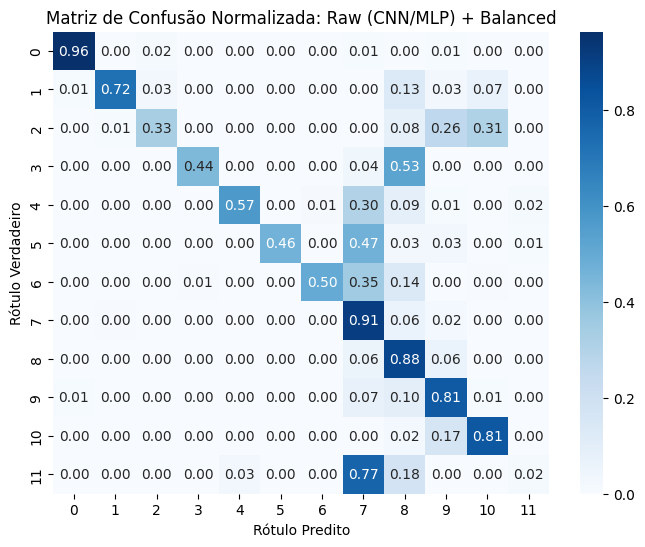


 Raw (CNN/MLP) + Optimized

 [Optuna] Otimizando DL (raw)...

 Treinando: Raw (CNN/MLP) + Optimized...


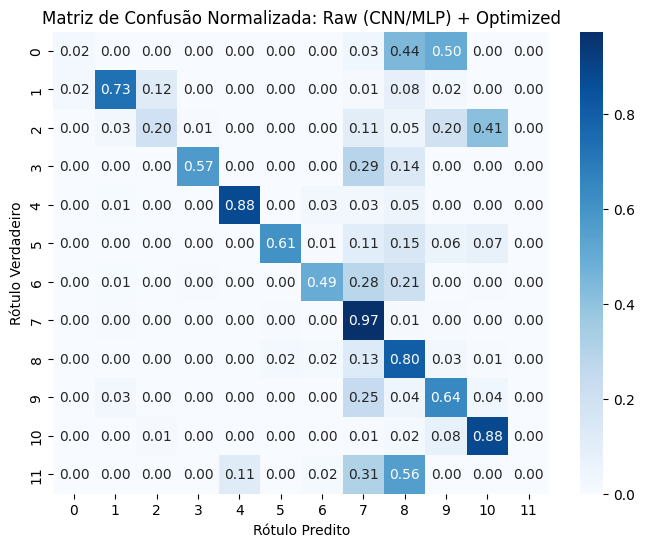


 Features (CNN/MLP) + Balanced

 Treinando: Features (CNN/MLP) + Balanced...


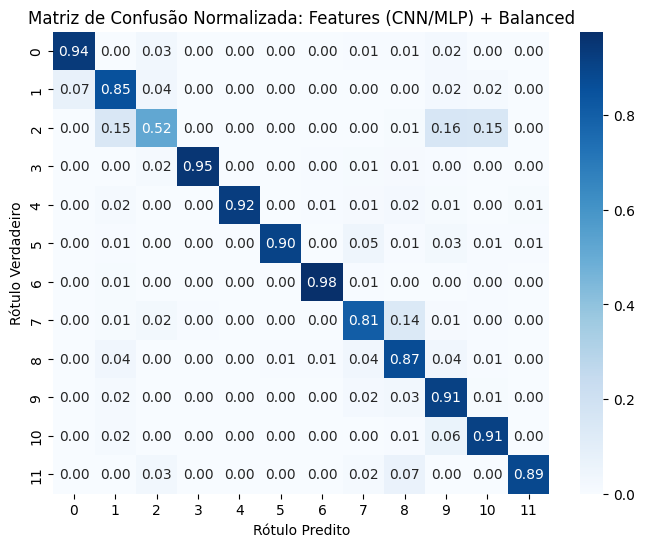


 Features (CNN/MLP) + Optimized

 [Optuna] Otimizando DL (features)...

 Treinando: Features (CNN/MLP) + Optimized...


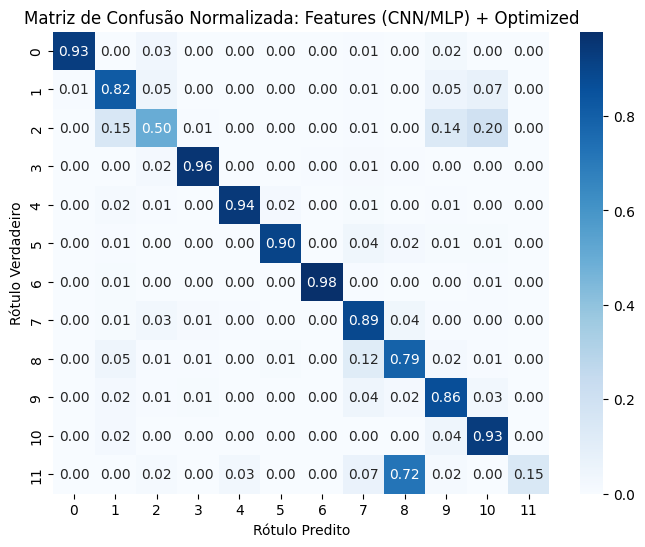



 RELATÓRIO FINAL: DEEP LEARNING (PAMAP2)


,Cenário,F1_Macro,F1_CI_Lower,F1_CI_Upper,Acurácia,Acc_CI_Lower,Acc_CI_Upper,Tempo_Treino_s
0,Raw (CNN/MLP) + Balanced,0.597509,0.584130,0.611004,0.644517,0.629826,0.658784,30.20
1,Raw (CNN/MLP) + Optimized,0.523623,0.512296,0.535429,0.598067,0.582758,0.613429,17.51
2,Features (CNN/MLP) + Balanced,0.865928,0.854658,0.877058,0.876855,0.867272,0.887072,11.28
3,Features (CNN/MLP) + Optimized,0.803136,0.787408,0.819645,0.861347,0.850386,0.871875,13.06


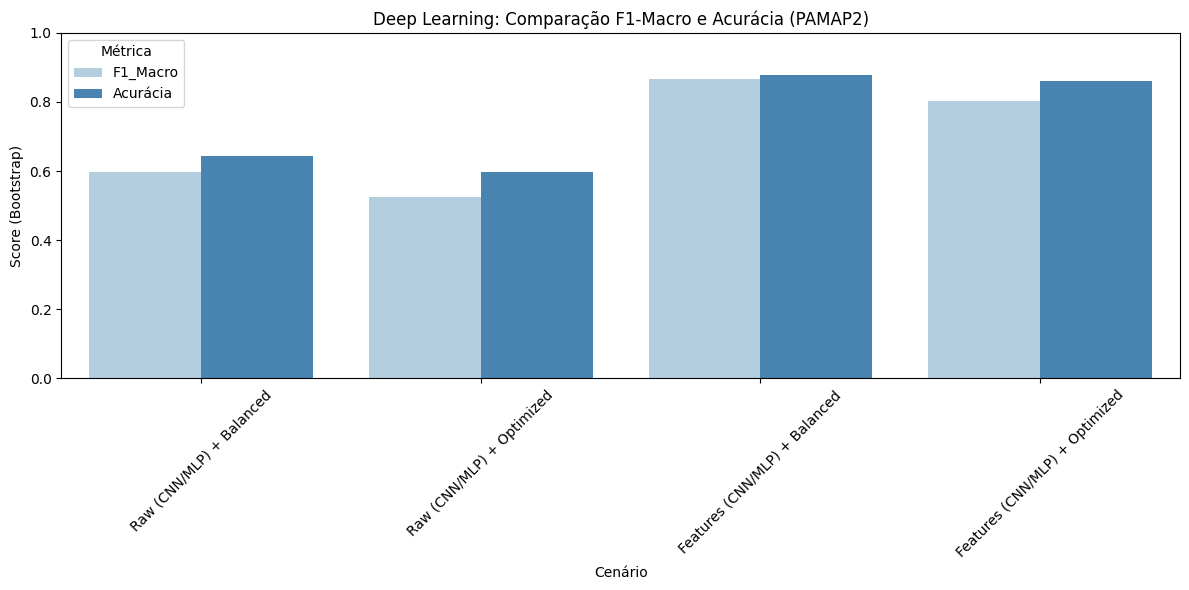

In [42]:
# ==========================================
# 4. EXECUÇÃO PRINCIPAL
# ==========================================
from IPython.display import display

splits = load_data_and_split(NPZ_PATH)

if splits:
    (X_train, y_train), (X_val, y_val), (X_test, y_test), NUM_CLASSES = splits
    final_report = []

    scenarios = [
        ("Raw", "balanced"),
        ("Raw", "optimized"),
        ("Features", "balanced"),
        ("Features", "optimized")
    ]

    for data_type, param_type in scenarios:
        scenario_label = f"{data_type} (CNN/MLP) + {param_type.capitalize()}"
        print(f"\n{'='*60}")
        print(f" {scenario_label}")
        print(f"{'='*60}")

        mode = 'raw' if data_type == 'Raw' else 'features'

        # We now use the explicit Subject-Independent validation set everywhere
        X_train_sc, X_val_sc, X_test_sc = prep_dl_data(X_train, X_val, X_test, mode)

        if param_type == 'optimized':
            best_params = run_optuna_dl(X_train_sc, y_train, X_val_sc, y_val, mode, NUM_CLASSES)
        else:
            best_params = 'balanced'

        res = run_experiments_dl(
            X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test,
            best_params, mode, NUM_CLASSES, scenario_label
        )

        final_report.append(res)
        gc.collect()

    df_results = pd.DataFrame(final_report)
    print("\n\n RELATÓRIO FINAL: DEEP LEARNING (PAMAP2)")
    display(df_results)

    # Histograma (Barplot) Azul Comparativo
    df_melted = df_results.melt(
        id_vars='Cenário',
        value_vars=['F1_Macro', 'Acurácia'],
        var_name='Métrica',
        value_name='Score'
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melted, x='Cenário', y='Score', hue='Métrica', palette='Blues')
    plt.title('Deep Learning: Comparação F1-Macro e Acurácia (PAMAP2)')
    plt.ylabel('Score (Bootstrap)')
    plt.ylim(0.0, 1.0)
    plt.xticks(rotation=45)
    plt.legend(title='Métrica')
    plt.tight_layout()
    plt.show()

else:
    print(" Falha no carregamento.")